# AIO Gap-Miner — predicting AI Overview citations

**Problem.** Google's AI Overviews (and ChatGPT / Perplexity / Claude) answer
informational queries at the top of the page and cite a *handful* of sources.
If your URL isn't in that citation set, your ranking position barely matters —
the click never happens. This project predicts, for a given query, **which
candidate URLs get cited**, and — via SHAP — **explains why**.

**Unit of observation.** One row per **(query, URL)** pair. Label `cited = 1`
if the URL was cited in the AI Overview for that query, else `0`.

**Why this is the right framing.**

| Decision | Choice | Reason |
|---|---|---|
| Task | Binary classification over (query, URL) pairs | Citation is a per-candidate yes/no |
| Model | LightGBM (gradient-boosted trees) | Tabular, mixed feature types, non-linear, fast |
| Validation | **GroupKFold** grouped by `query_id` | Labels are query-relative → no query may leak across the split |
| Metric | **PR-AUC** (average precision) | Positives are rare (~17%) and query-relative; ROC-AUC/accuracy flatter the model |
| Explainability | **TreeSHAP** | Exact per-feature attribution → auditable "why", the differentiator vs a black box |

> The committed sample data is **synthetic** (see `data/sample/`) so this
> notebook runs for anyone with zero data access. The numbers below therefore
> demonstrate the *method*, not real-world findings. Drop a real labelled CSV
> with the same schema into `data/raw/` to reproduce on live data.

## 1 — Setup

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aio_gap_miner import config
from aio_gap_miner.data import load_dataset
from aio_gap_miner.features import build_xy
from aio_gap_miner.model import run_group_kfold_cv, train_final_model
from aio_gap_miner import evaluate as ev
from aio_gap_miner import explain as ex

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
RANDOM_SEED = config.RANDOM_SEED
np.random.seed(RANDOM_SEED)
print("aio_gap_miner ready — features:", len(config.FEATURES))

aio_gap_miner ready — features: 19


## 2 — Load the data
One row per (query, URL) candidate.

In [2]:
df = load_dataset()  # defaults to the committed synthetic sample
print(f"{len(df):,} rows | {df[config.GROUP_COL].nunique():,} queries "
      f"| positive rate {df[config.TARGET].mean():.1%}")
df.head()

7,361 rows | 400 queries | positive rate 17.1%


,query_id,query,url,organic_rank,domain_rating,page_authority,word_count,has_schema,num_lists_tables,has_faq,query_url_similarity,passage_match_score,content_freshness_days,num_entities_matched,readability_score,is_https,domain_citation_rate,is_forum,is_video,content_type,cited
0,q0000,how to descale an espresso machine,https://example0000.com/page-0,15,40.7,47.7,1271,0,2,0,0.508,0.582,164,5,60.1,1,0.184,0,0,informational,0
1,q0000,how to descale an espresso machine,https://example0000.com/page-1,15,43.9,45.7,1144,1,1,0,0.555,0.576,158,8,60.4,1,0.195,0,0,transactional,0
2,q0000,how to descale an espresso machine,https://example0000.com/page-2,22,60.1,65.6,1317,1,1,0,0.400,0.503,161,10,44.7,1,0.195,0,0,informational,1
3,q0000,how to descale an espresso machine,https://example0000.com/page-3,1,84.3,84.9,872,0,1,0,0.675,0.610,114,12,67.5,1,0.426,0,0,informational,1
4,q0000,how to descale an espresso machine,https://example0000.com/page-4,19,61.6,64.0,560,0,1,1,0.580,0.603,155,7,61.5,1,0.259,0,0,informational,0


## 3 — Exploratory analysis

### 3.1 Class balance and candidates per query
Citation is rare and query-relative — this is exactly the regime where PR-AUC is the honest metric.

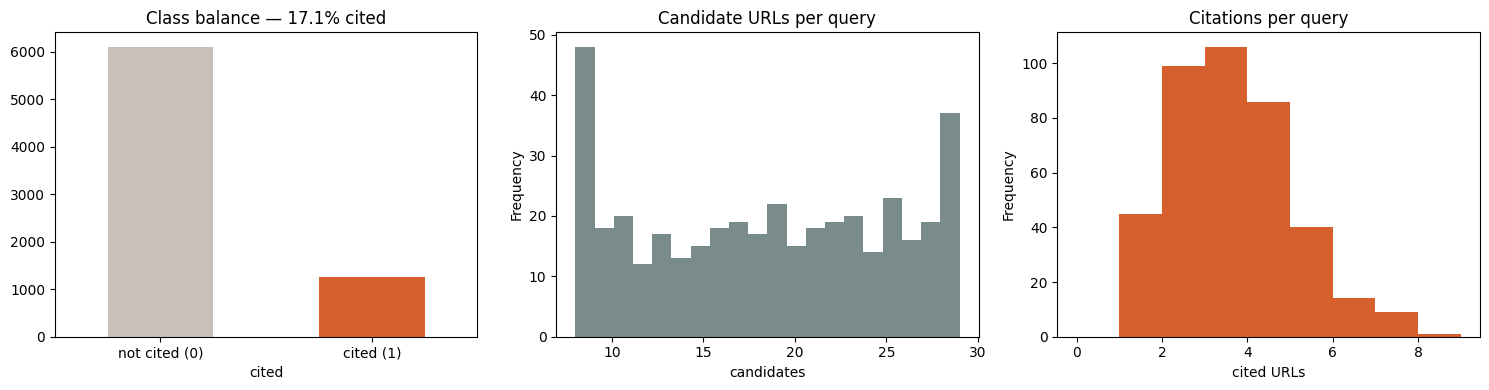

       candidates   cited
count      400.00  400.00
mean        18.40    3.15
std          6.52    1.43
min          8.00    1.00
25%         13.00    2.00
50%         19.00    3.00
75%         24.00    4.00
max         29.00    8.00


In [3]:
per_query = df.groupby(config.GROUP_COL).agg(
    candidates=("url", "size"),
    cited=(config.TARGET, "sum"),
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df[config.TARGET].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#c7c1b8", "#d5602e"])
axes[0].set_title(f"Class balance — {df[config.TARGET].mean():.1%} cited")
axes[0].set_xticklabels(["not cited (0)", "cited (1)"], rotation=0)

per_query["candidates"].plot(kind="hist", bins=20, ax=axes[1], color="#7a8b8b")
axes[1].set_title("Candidate URLs per query")
axes[1].set_xlabel("candidates")

per_query["cited"].plot(kind="hist", bins=range(0, 10), ax=axes[2], color="#d5602e")
axes[2].set_title("Citations per query")
axes[2].set_xlabel("cited URLs")
plt.tight_layout(); plt.show()

print(per_query.describe().round(2))

### 3.2 Which raw signals separate cited from non-cited?
A first, model-free look: mean feature value by class. Large gaps hint at predictive features (semantic match, structure, rank).

In [4]:
signal_cols = ["organic_rank", "query_url_similarity", "passage_match_score",
               "domain_rating", "domain_citation_rate", "num_lists_tables",
               "has_schema", "has_faq", "num_entities_matched", "word_count"]
by_class = df.groupby(config.TARGET)[signal_cols].mean().T
by_class.columns = ["not cited", "cited"]
by_class["abs_gap"] = (by_class["cited"] - by_class["not cited"]).abs()
by_class.sort_values("abs_gap", ascending=False).round(3)

,not cited,cited,abs_gap
word_count,1580.810,1730.555,149.745
domain_rating,61.394,70.073,8.679
organic_rank,12.099,6.887,5.213
num_entities_matched,7.924,9.479,1.556
num_lists_tables,2.612,3.593,0.981
has_schema,0.488,0.664,0.176
passage_match_score,0.543,0.715,0.172
query_url_similarity,0.548,0.692,0.144
has_faq,0.329,0.472,0.143
domain_citation_rate,0.295,0.330,0.036


## 4 — Feature engineering
`build_xy` adds two domain-motivated features — `rank_reciprocal` (1/rank, the non-linear visibility decay) and `structure_score` (a single 'how extractable is this page' signal) — and casts categoricals to pandas `category` dtype so LightGBM handles them natively.

In [5]:
X, y, groups = build_xy(df)
print("X shape:", X.shape)
print("categoricals:", [c for c in X.columns if str(X[c].dtype) == 'category'])
print("any NaNs in X:", bool(X.isna().any().any()))
X.head(3)

X shape: (7361, 19)
categoricals: ['content_type']
any NaNs in X: False


,organic_rank,rank_reciprocal,domain_rating,page_authority,word_count,has_schema,num_lists_tables,has_faq,structure_score,query_url_similarity,passage_match_score,content_freshness_days,num_entities_matched,readability_score,is_https,domain_citation_rate,is_forum,is_video,content_type
0,15,0.066667,40.7,47.7,1271,0,2,0,0.08,0.508,0.582,164,5,60.1,1,0.184,0,0,informational
1,15,0.066667,43.9,45.7,1144,1,1,0,0.44,0.555,0.576,158,8,60.4,1,0.195,0,0,transactional
2,22,0.045455,60.1,65.6,1317,1,1,0,0.44,0.400,0.503,161,10,44.7,1,0.195,0,0,informational


## 5 — Leakage-safe cross-validation
`GroupKFold(groups=query_id)` keeps every query wholly inside one fold. We collect **out-of-fold** predictions so the headline metric is genuinely held-out.

In [6]:
cv = run_group_kfold_cv(X, y, groups, verbose=True)
print(f"\nPer-fold PR-AUC: {cv.mean_ap:.4f} +/- {cv.std_ap:.4f}")

  fold 1/5  PR-AUC = 0.5926  (best_iter=93)
  fold 2/5  PR-AUC = 0.5793  (best_iter=75)


  fold 3/5  PR-AUC = 0.5521  (best_iter=60)
  fold 4/5  PR-AUC = 0.5868  (best_iter=36)


  fold 5/5  PR-AUC = 0.5511  (best_iter=37)

Per-fold PR-AUC: 0.5724 +/- 0.0175


## 6 — Evaluation vs baselines
The bar to clear isn't zero — it's the **rank-only heuristic** (predict citation from organic position alone). If the learned model doesn't beat that, it isn't earning its keep.

In [7]:
summary = ev.evaluation_summary(df, cv.oof_pred)

rows = [
    ("PR-AUC (average precision)", summary["model_pr_auc"], summary["rank_only_pr_auc"], summary["positive_rate"]),
    ("ROC-AUC",                    summary["model_roc_auc"], summary["rank_only_roc_auc"], 0.5),
    ("Precision@k (per query)",    summary["precision_at_true_k_model"], summary["precision_at_true_k_rank"], np.nan),
]
comp = pd.DataFrame(rows, columns=["metric", "Gap-Miner", "rank-only", "random / prevalence"]).set_index("metric")
print(comp.round(4).to_string())
print(f"\nLift over rank-only (PR-AUC): +{summary['lift_over_rank']:.3f}")
print(f"Lift over prevalence (PR-AUC): +{summary['lift_over_prevalence']:.3f}")

                            Gap-Miner  rank-only  random / prevalence
metric                                                               
PR-AUC (average precision)     0.5365     0.4803               0.1712
ROC-AUC                        0.8080     0.7568               0.5000
Precision@k (per query)        0.5909     0.5260                  NaN

Lift over rank-only (PR-AUC): +0.056
Lift over prevalence (PR-AUC): +0.365


### 6.1 Precision-Recall curve

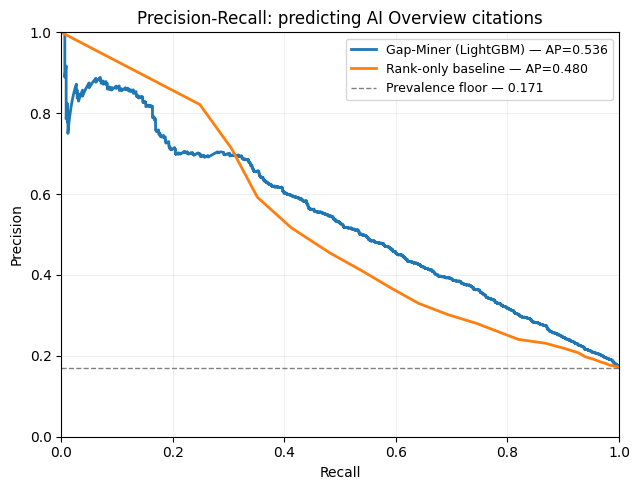

In [8]:
fig, ax = ev.plot_pr_curves(df, cv.oof_pred)
plt.show()

### 6.2 Confusion matrix at the F1-optimal threshold

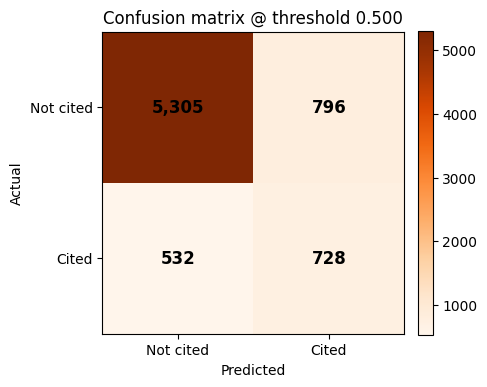

Operating threshold: 0.500  |  F1 = 0.523


In [9]:
fig, ax = ev.plot_confusion(df, cv.oof_pred, threshold=summary["best_f1_threshold"])
plt.show()
print(f"Operating threshold: {summary['best_f1_threshold']:.3f}  |  F1 = {summary['best_f1']:.3f}")

## 7 — Explainability (TreeSHAP)
Why does a URL get cited? We train a final model on all rows (at the mean best CV iteration) and attribute predictions with TreeSHAP.

In [10]:
mean_best_iter = int(np.mean(cv.best_iterations))
final_model = train_final_model(X, y, n_estimators=mean_best_iter)
explainer, shap_values = ex.compute_shap_values(final_model, X)

importance = ex.mean_abs_importance(shap_values, list(X.columns))
importance.head(10)

,feature,mean_abs_shap
0,query_url_similarity,0.335827
1,organic_rank,0.279193
2,passage_match_score,0.224022
3,structure_score,0.151208
4,rank_reciprocal,0.075823
5,domain_rating,0.068462
6,content_freshness_days,0.058927
7,num_entities_matched,0.057331
8,is_forum,0.047126
9,page_authority,0.043819


### 7.1 Global importance and direction (beeswarm)
Each dot is a (query, URL) row. Colour = feature value, x-position = push toward (right) or away from (left) citation.

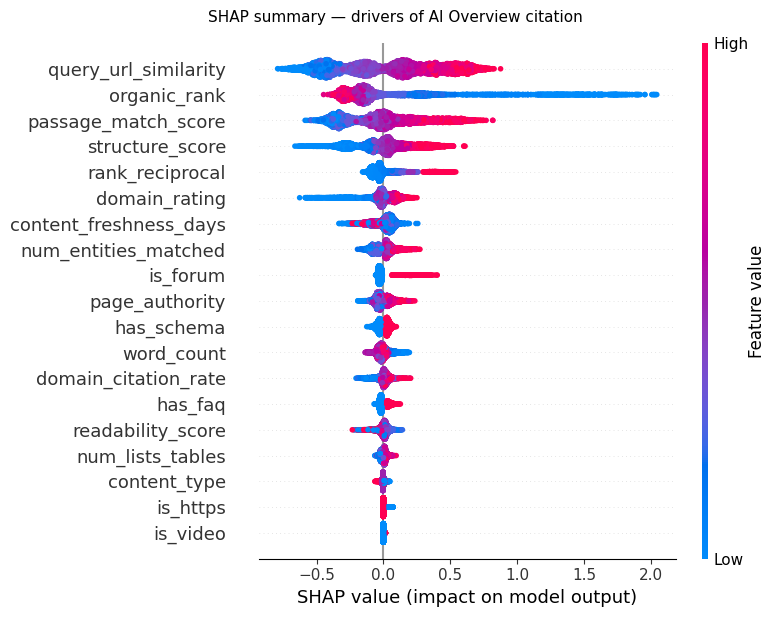

In [11]:
ex.plot_beeswarm(shap_values, X)
plt.show()

### 7.2 Response curve for the top driver

<Figure size 650x500 with 0 Axes>

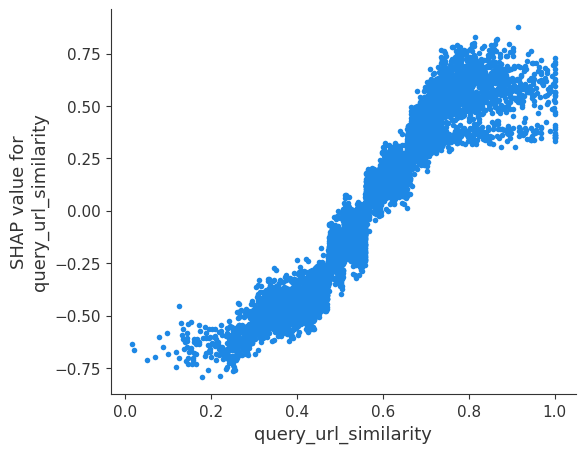

Top driver: query_url_similarity


In [12]:
top_feature = importance.iloc[0]["feature"]
ex.plot_dependence(shap_values, X, top_feature)
plt.show()
print("Top driver:", top_feature)

## 8 — Read-out & next steps

**What the method shows (on synthetic data).** The learned model beats a strong
rank-only heuristic on PR-AUC and on per-query precision@k, and SHAP attributes
the edge to **semantic passage match, content structure, and domain citation
history** — signals that raw ranking position can't see. That is precisely the
GEO thesis, made measurable: *structured, on-topic pages get cited beyond what
their SERP position alone would predict.*

**From here:**

1. **Real labels.** Swap the synthetic sample for labelled AI Overview citation
   data (same schema) — the OnPagePilot partnership set. No pipeline changes
   needed.
2. **Richer features.** Real embeddings for query↔passage similarity, entity
   coverage from an NER pass, SERP feature flags, page-speed / Core Web Vitals.
3. **Calibration.** `is_unbalance` optimises ranking, not calibrated
   probabilities — add isotonic/Platt calibration if absolute probabilities are
   needed for a "citation likelihood" score.
4. **The product angle.** Per (query, URL) SHAP values become a *gap report*:
   for a page you *don't* own the citation on, SHAP names the specific levers
   (add FAQ schema, tighten the answer passage, raise topical coverage) to close
   the gap. This is the analytical layer a rules-based tool can't offer.